# Statistical Analysis of Pupil Data

```{admonition} Overview
PupEyes is designed for **preprocessing**: preparing your data in an analysis-friendly format so you can perform whatever analyses that you deem appropriate for your research goals onward. Indeed, there are [many ways to analyze pupil size data](https://link.springer.com/book/10.1007/978-3-031-54896-3), and it would be impractical to implement them all. However, to demonstrate how easily you can conduct analyses with preprocessed `PupEyes` data, we will cover some basic examples:

1. **Using a Predefined Time Window**

2. **Plotting Evoked Responses**

3. **Cluster-based Permutation Testing**

```

```{note} 
Some analyses in this tutorial require the `mne` package, a Python library for visualizing and analyzing neurophysiological data. **`mne` is not included as a dependency for PupEyes**. For information on how to install, see: https://mne.tools/stable/install/index.html
```

## Example Task

Suppose our example memory task has a within-subject condition called "**memory load**." On low-load trials, only 3 letters were presented. On high-load trials, 6 letters were presented.
We are interested in **whether high-load trials elicit a larger task-evoked pupillary response than low-load trials**. This is a common scenario in which task-evoked pupillary responses are compared between the levels of a within-subject factor.

```{image} assets/trial.png
:alt: asc_file
:width: 800px
:align: center
```


First, let's generate some fake pupil data for this task.

In [1]:
import pandas as pd
import pupeyes as pe
from pupeyes.pupil import _generate_pupil_data

%matplotlib inline

In [2]:
data_within =_generate_pupil_data(condition_names=['high load','low load'])

data_within.groupby(['participant', 'condition']).trial.nunique()

participant  condition
P1           high load    10
             low load     10
P2           high load    10
             low load     10
P3           high load    10
             low load     10
P4           high load    10
             low load     10
P5           high load    10
             low load     10
P6           high load    10
             low load     10
Name: trial, dtype: int64

We have generated a pupil dataset for a within-subject design, with 6 participants completing 10 trials in each condition.

## Pupil Preprocessing

Since our focus here is on statistical analyses, I'm going to quickly do preprocessing using a set of default choices and skip diagnostics. For real data, though, this is probably not a good idea unless you know what you are doing. Check out the [Pupil Preprocessing tutorial](pupil_preproc.ipynb) for more information on pupil preprocessing steps.

In [3]:
def my_pipeline(data):
    """This is probably not a good idea for real data.
    """
    # Do preprocessing
    p = pe.PupilProcessor(
        data=data_within,
        trial_identifier=['participant', 'condition', 'trial'],
        x_col = 'x',
        y_col = 'y',
        pupil_col = 'pp',
        time_col = 'trialtime',
        samp_freq = 1000,
        convert_pupil_size=False,
        progress_bar=False
        )\
        .deblink()\
        .artifact_rejection()\
        .smooth()\
        .interpolate(missing_threshold=.4)\
        .baseline_correction(baseline_query='event=="fixation"', baseline_range=[-100, None])
    
    # Create a final dataset with only valid trials during stimulus presentation
    p.final_data = p.data.query('event=="stimulus"').reset_index(drop=True)
    
    # Rename the fully preprocessed pupil column to something more manageable
    p.final_data['pp_final'] = p.final_data['pp_db_ar_sm_it_bc']
    
    # Select only the relevant columns for analysis
    p.final_data = p.final_data[[
        'condition',    # condition
        'participant',  # participant ID
        'trial',        # trial number
        'event',        # event marker
        'trialtime',    # time relative to trial onset
        'x', 'y',       # gaze coordinates
        'pp_final'      # preprocessed pupil size
    ]]
    
    # Create a timestamp column indicating time since stimulus onset using pandas' groupby-transform routine
    p.final_data['eventtime'] = p.final_data.groupby(['participant','condition','trial'], sort=False).trialtime.transform(lambda x: x - x.iloc[0]) # reset timestamp for each trial

    return p

p = my_pipeline(data_within)

# Preview the data
p.final_data.head(5)

Sampling frequency check passed.
PupilProcessor initialized with 300000 samples
Pupil column: pp, Time column: trialtime, X column: x, Y column: y
Trial identifier: ['participant', 'condition', 'trial'], Number of trials: 120


,condition,participant,trial,event,trialtime,x,y,pp_final,eventtime
0,low load,P1,1,stimulus,500,942.185932,507.713273,0.005327,0
1,low load,P1,1,stimulus,501,996.015392,540.323535,0.00529,1
2,low load,P1,1,stimulus,502,941.540018,553.377994,0.005231,2
3,low load,P1,1,stimulus,503,968.662738,557.507127,0.005151,3
4,low load,P1,1,stimulus,504,956.29782,517.937173,0.005055,4


OK. Now we prepare a final dataset for analysis:

## Use a Predefined Time Window

If you have a (preferably pre-registered) hypothesis for when your task-evoked pupillary response will emerge, you can simply select that time window and compute the mean pupil size within that window.

For example, if we hypothesize that the effect emerges during 600 ms to 1000 ms after stimulus onset:

In [4]:
df_600to1000 = p.final_data.query('eventtime > 600 & eventtime < 1000').groupby(['participant','condition','trial']).pp_final.mean() 
df_600to1000

participant  condition  trial
P1           high load  3        0.411048
                        5       -0.001736
                        8       -0.004048
                        9       -0.006161
                        11       0.865803
                                   ...   
P6           low load   13        0.42528
                        15      -0.002152
                        16       0.292533
                        19       0.309909
                        20       0.094568
Name: pp_final, Length: 120, dtype: Float64

From now on, mean pupil sizes can be analyzed in the same way as response times (RTs).

## Plot Evoked Response

Oftentimes we do not have a hypothesis about when an effect should emerge. Even if we do, it is always nice to have a plot showing the entire evoked response. PupEyes has a built-in method, `.plot_evoked()`, to plot evoked responses. For example, the plot below shows grand average pupillary responses and their associated confidence bands for conditions A and B.

Data will be padded to minimum length: 2000 samples
Condition {'condition': 'low load'}: Computing average from 60 trials
Condition {'condition': 'high load'}: Computing average from 60 trials


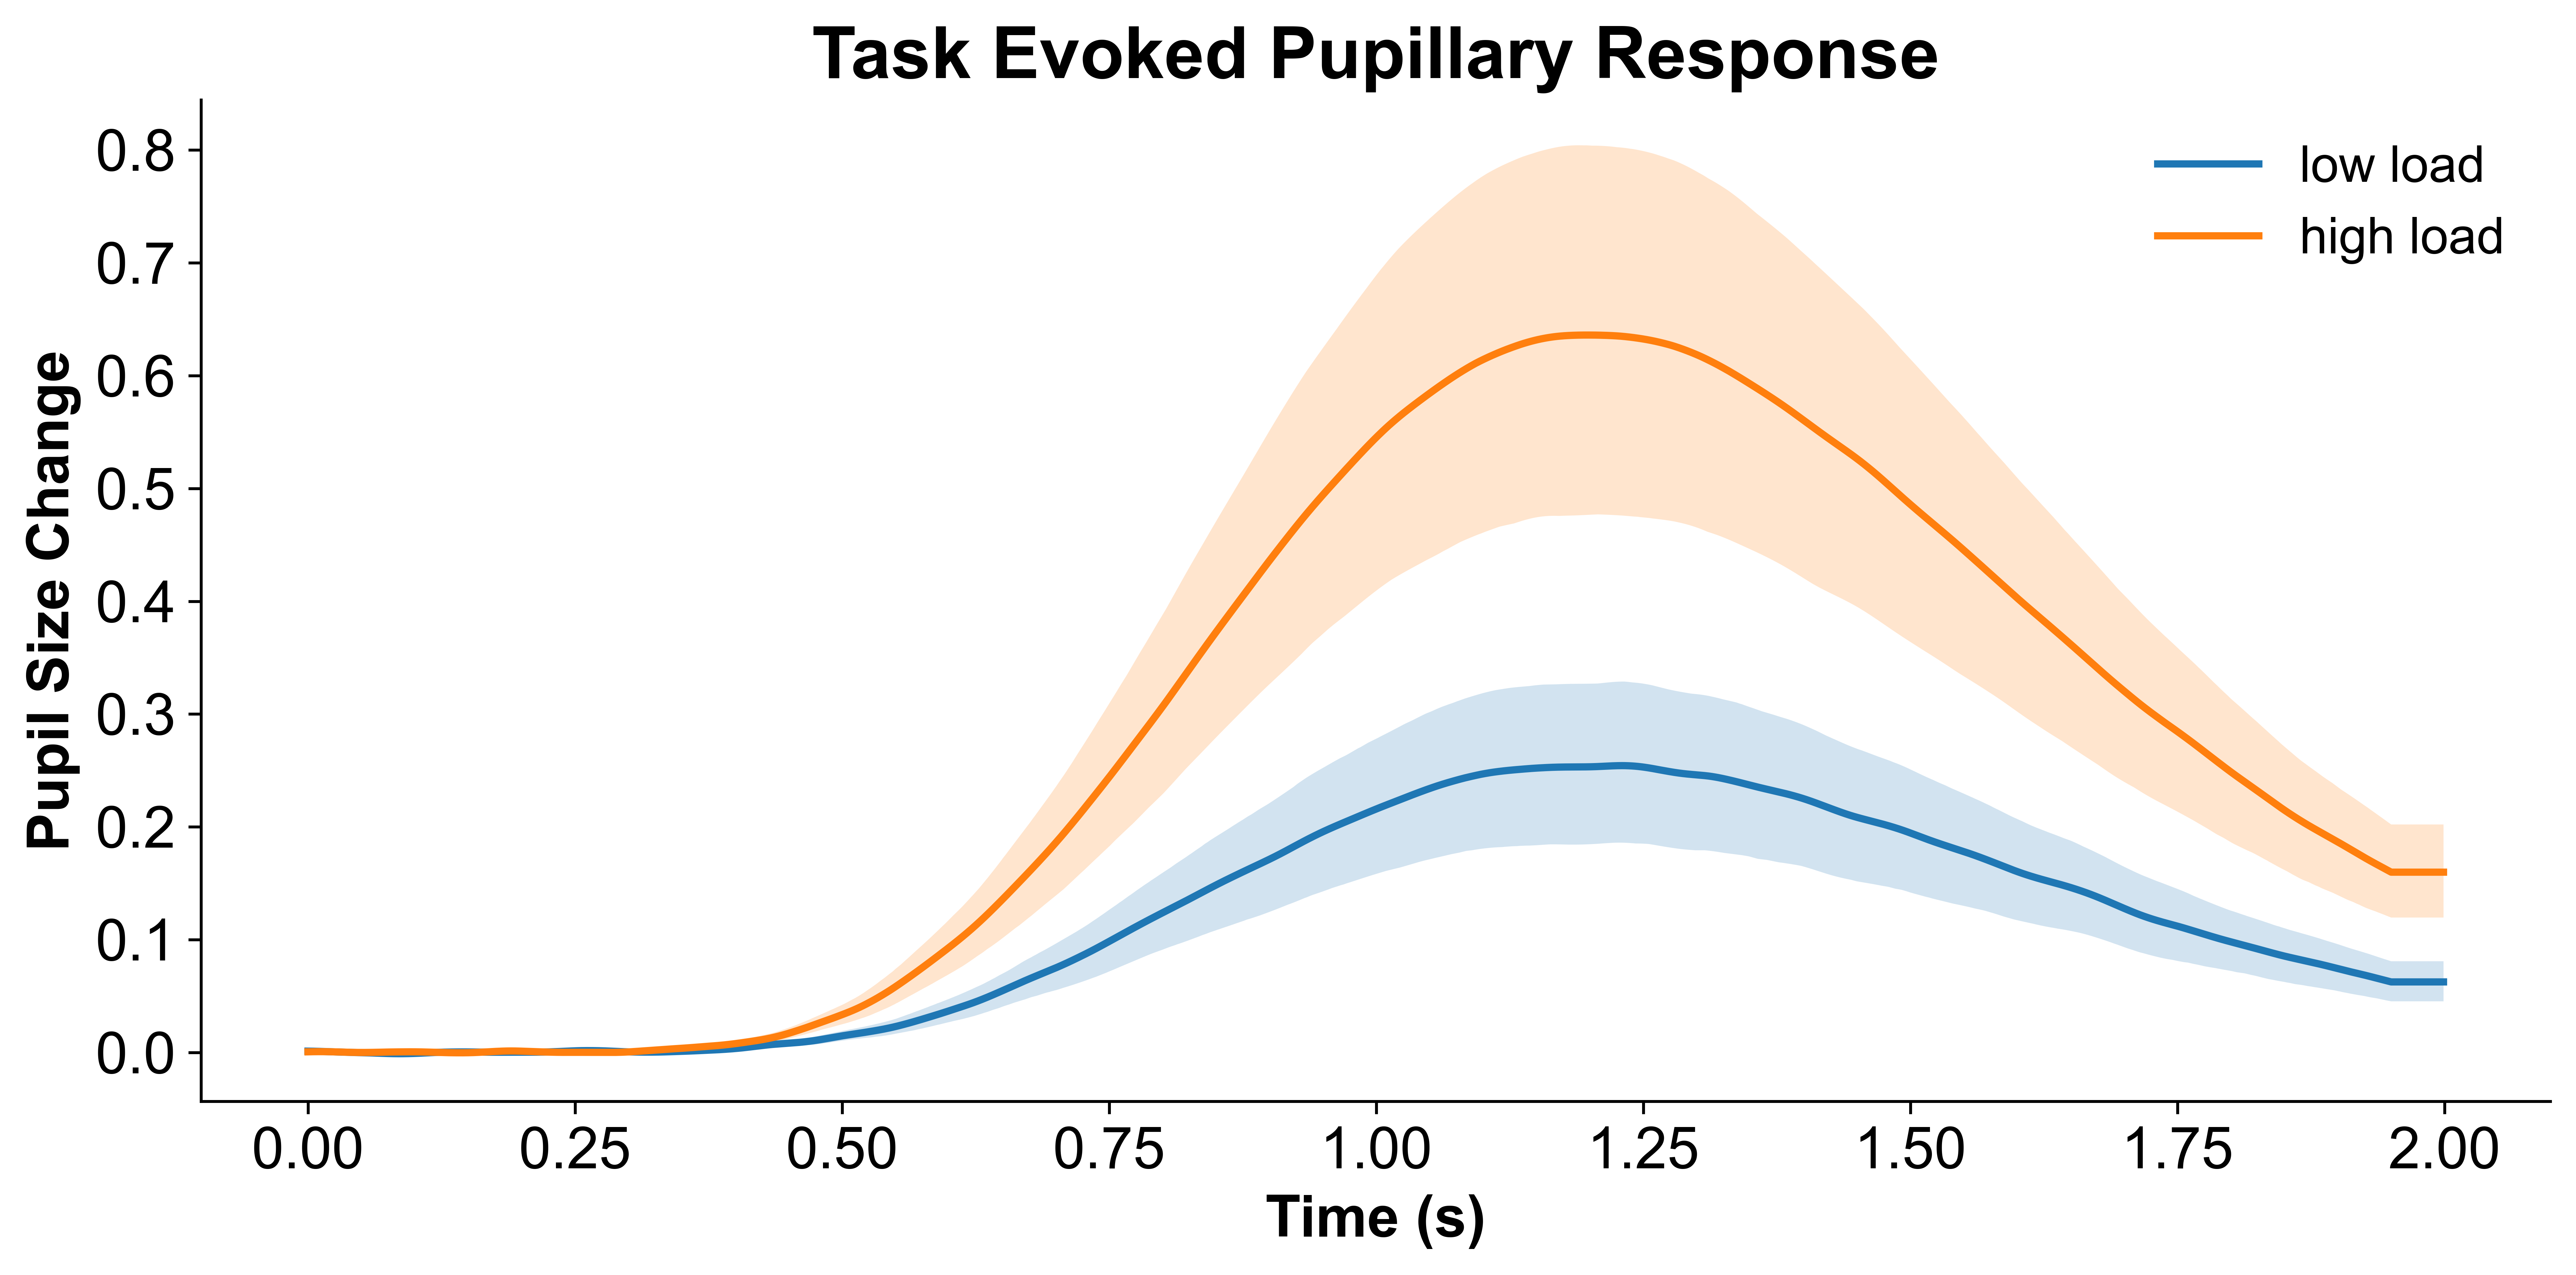

In [5]:
data_grandavg, (fig, ax) = p.plot_evoked(
    data='final_data', 
    condition='condition',
    pupil_col='pp_final', 
    error='ci',  # ci requires mne
)

We can also plot the evoked response for individual participants:

Data will be padded to minimum length: 2000 samples
Condition {'participant': 'P1', 'condition': 'low load'}: Computing average from 10 trials
Condition {'participant': 'P1', 'condition': 'high load'}: Computing average from 10 trials
Condition {'participant': 'P2', 'condition': 'low load'}: Computing average from 10 trials
Condition {'participant': 'P2', 'condition': 'high load'}: Computing average from 10 trials
Condition {'participant': 'P3', 'condition': 'low load'}: Computing average from 10 trials
Condition {'participant': 'P3', 'condition': 'high load'}: Computing average from 10 trials
Condition {'participant': 'P4', 'condition': 'high load'}: Computing average from 10 trials
Condition {'participant': 'P4', 'condition': 'low load'}: Computing average from 10 trials
Condition {'participant': 'P5', 'condition': 'low load'}: Computing average from 10 trials
Condition {'participant': 'P5', 'condition': 'high load'}: Computing average from 10 trials
Condition {'participant': 'P6', '

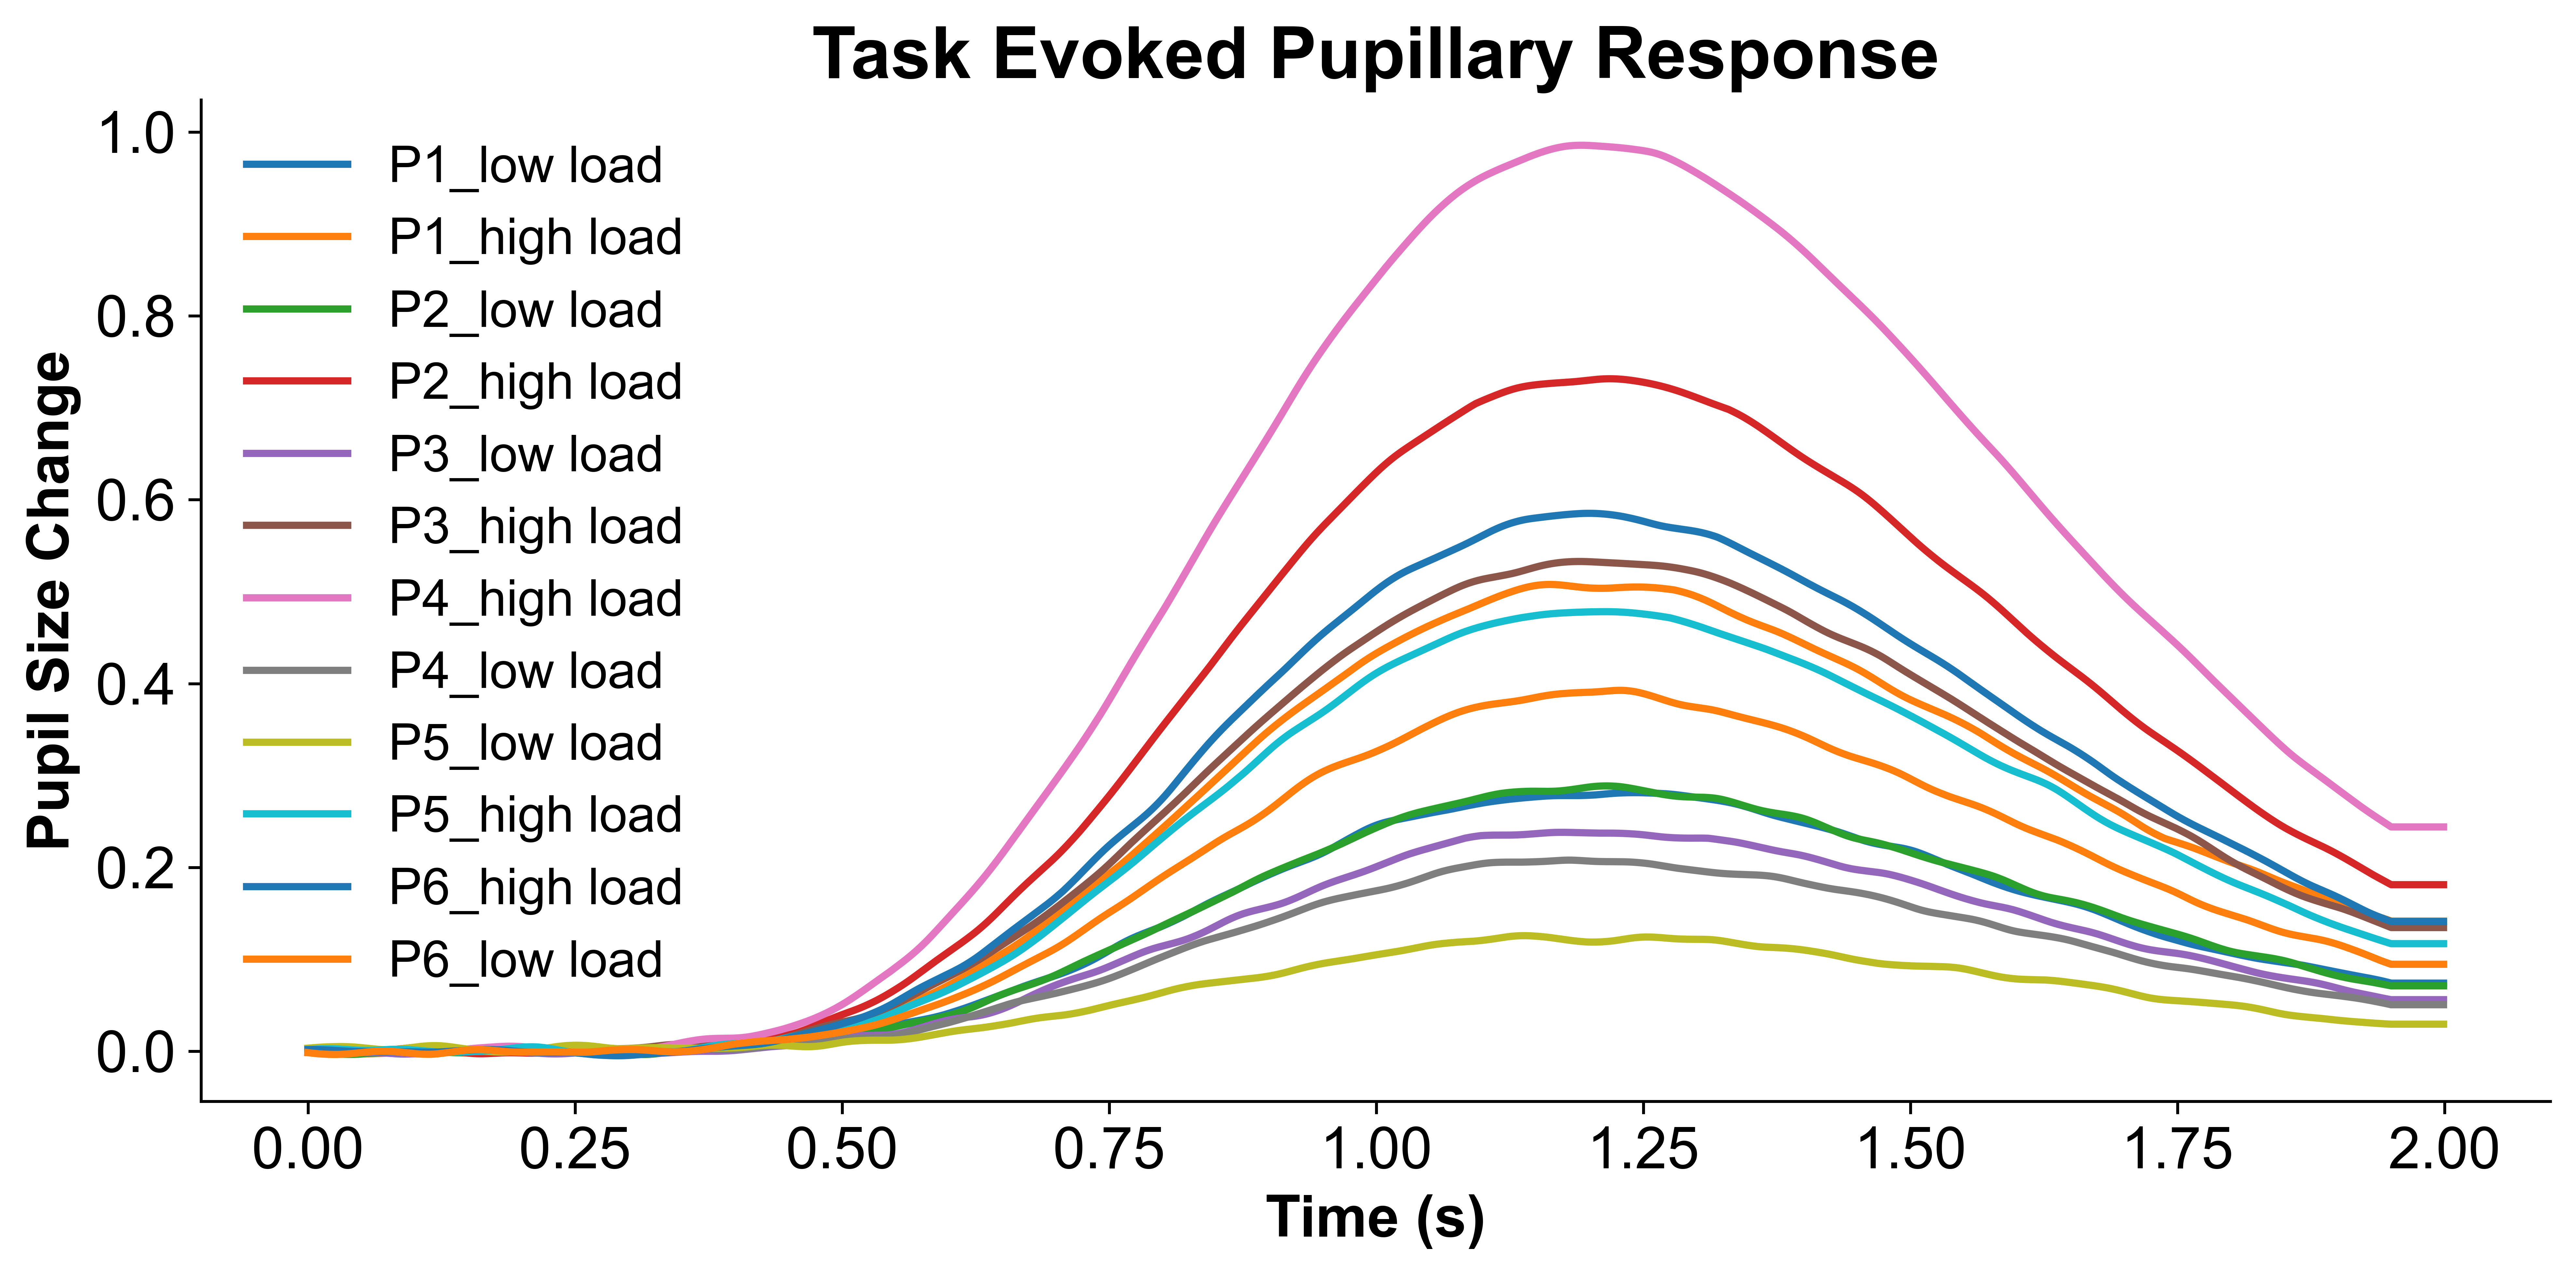

In [6]:
data_ind_subs, (fig, ax) = p.plot_evoked(
    data='final_data', 
    condition=['participant','condition'], # supports adding a list
    pupil_col='pp_final', 
    error=None # remove error band for better clarity
)

You can also aggregate the data before plotting. For example, specifying `agg_by='participant'` will compute an averaged trace for each participant first and then plot the data based on participant-level traces, much like computing a mean RT for each participant and then plotting the average RT across participants.

Data will be padded to minimum length: 2000 samples
Condition {'condition': 'low load'}: Computing average from 6 ['participant'] means
Condition {'condition': 'high load'}: Computing average from 6 ['participant'] means


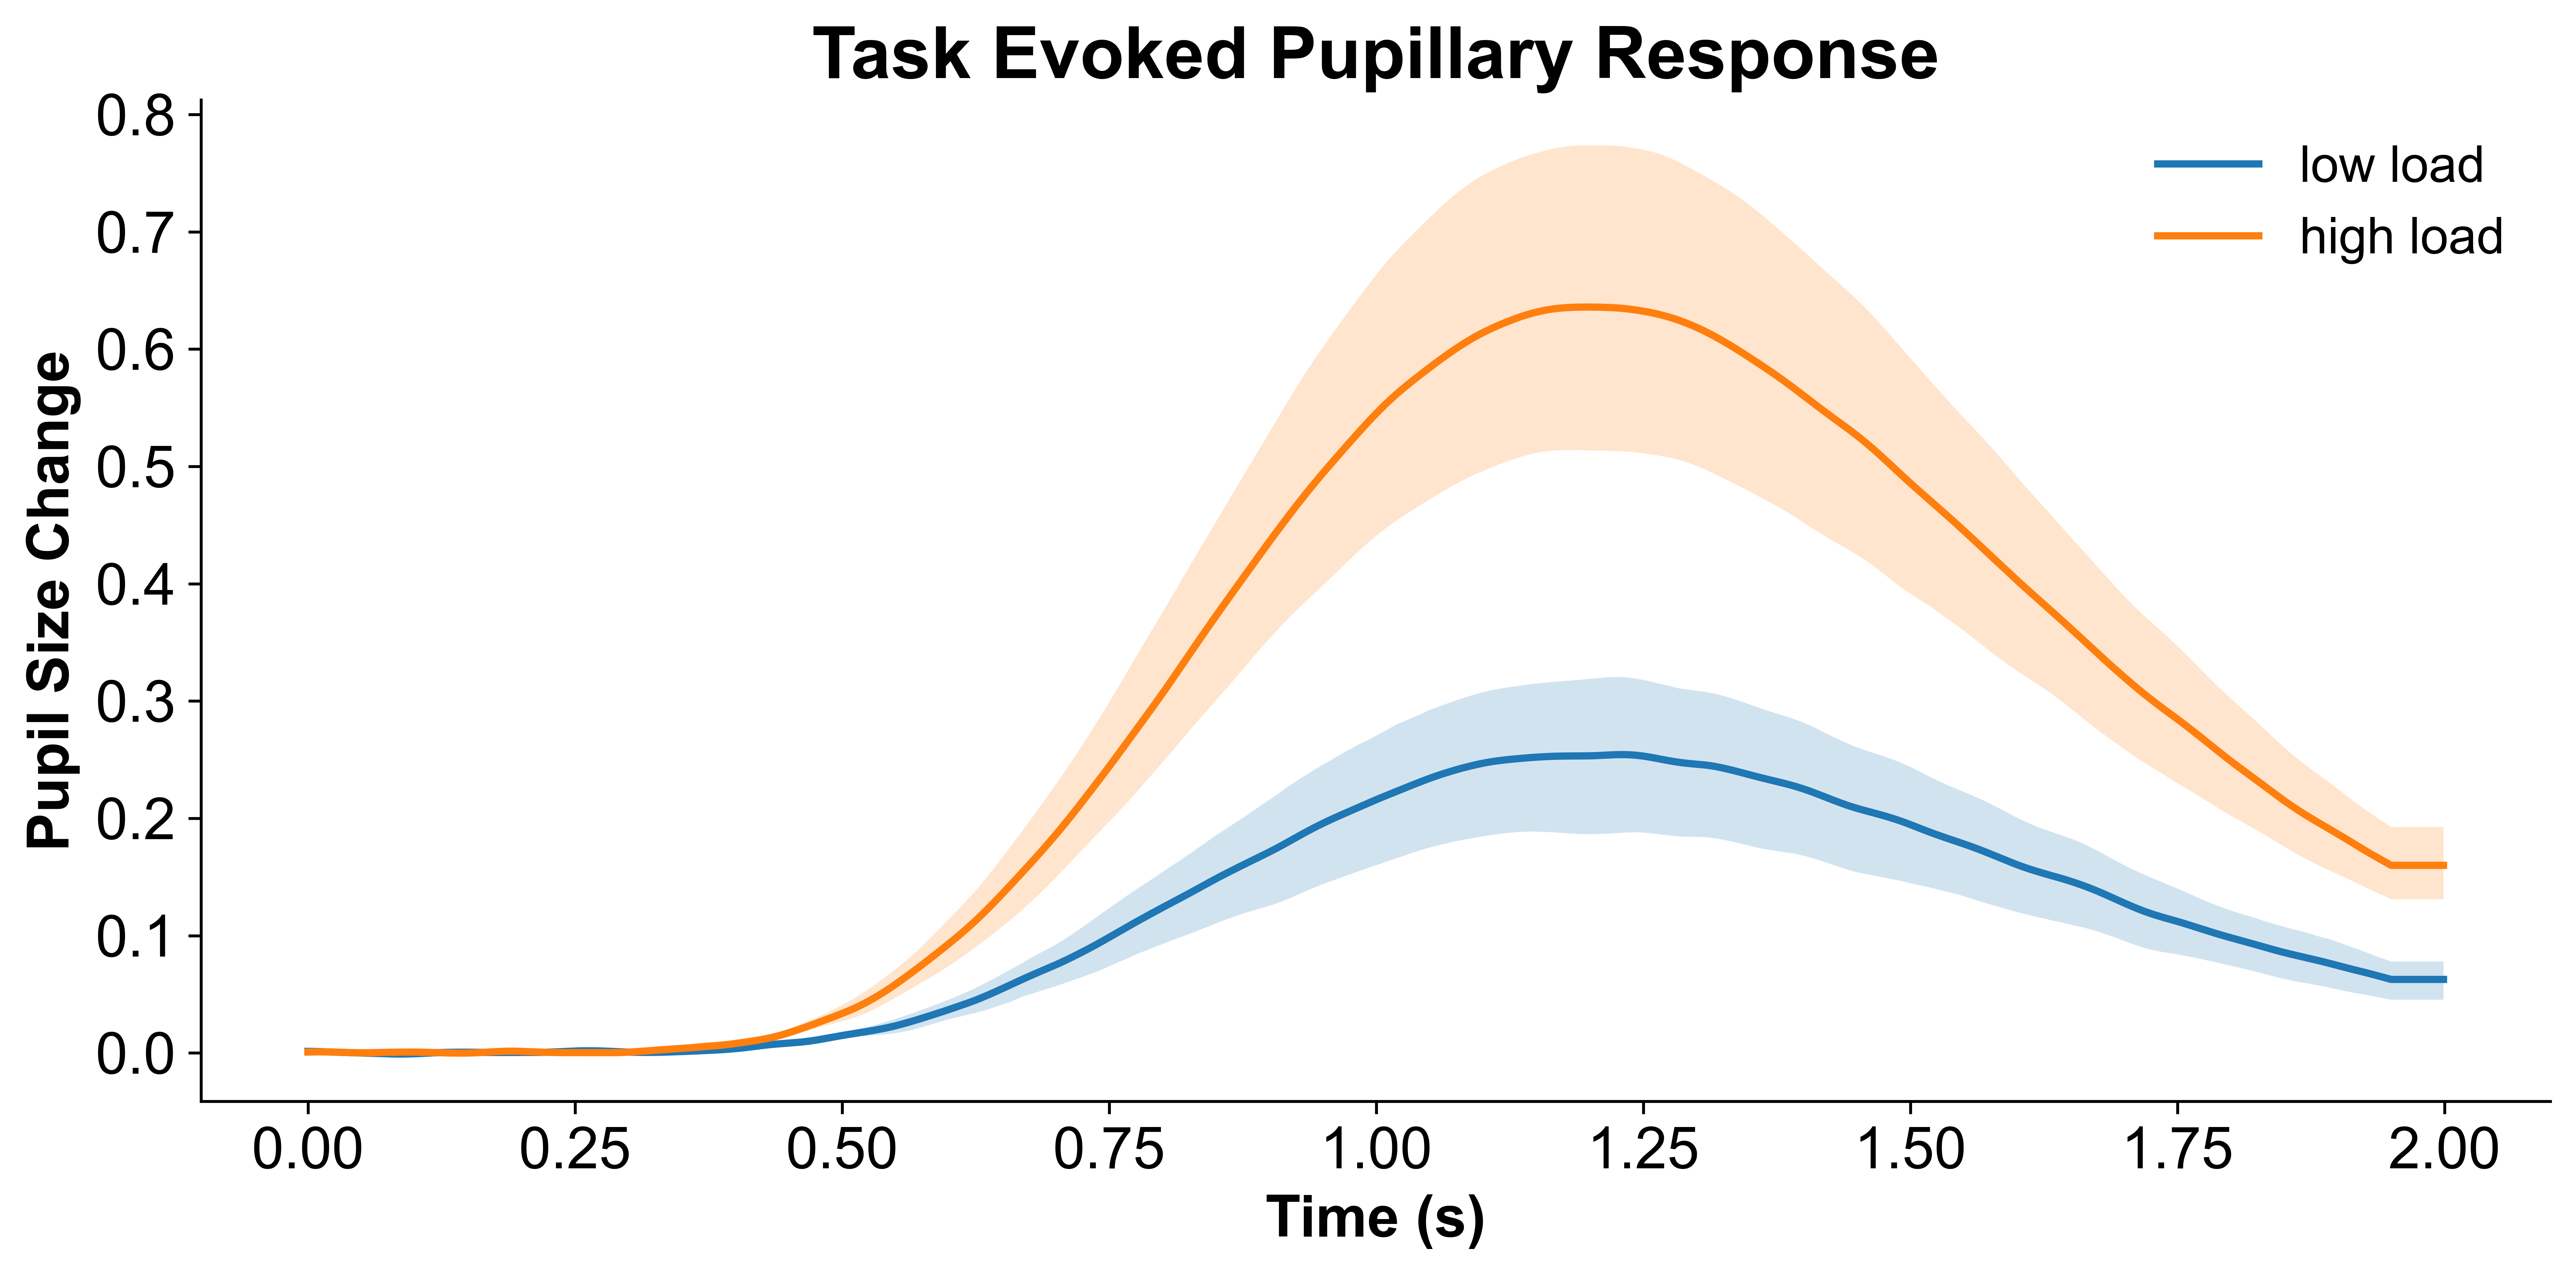

In [7]:
data_sub_level, (fig, ax) = p.plot_evoked(
    data='final_data', 
    agg_by='participant', # aggregate by participant
    condition='condition', 
    pupil_col='pp_final', 
    error='ci')

You might have noticed that `.plot_evoked()` not only returns the plot but also the data. The returned data will be discussed in the next section.

## Cluster-based Permutation Testing

**Does condition A elicit a statistically different pupillary response compared to condition B?** Pupil data easily consists of thousands of data points, which creates a multiple-comparison problem: If a statistical test is performed for every time point, it will easily end up having thousands of tests. Simply performing a Bonferroni correction seems too strict and limits statistical power. Therefore, it is common practice to conduct cluster-based permutation testing to determine whether the data is indistinguishable from chance (or from another condition).

The `.plot_evoked()` method not only returns the plot but also the data that the plot is based on. For example, `data_sub_level` is a dictionary with the two conditions (A and B) as keys. For each condition, the returned data is a 6*2500 array because we have 6 subjects with each subject having 2500 data points (i.e., 2500 ms with 1000 Hz sampling rate). Note that each data point is averaged across all trials within that participant. 

In [8]:
data_sub_level

{'low load': array([[ 0.00255182,  0.0025651 ,  0.00257478, ...,  0.07409407,
          0.07409407,  0.07409407],
        [ 0.0003461 ,  0.00029606,  0.00023656, ...,  0.07115299,
          0.07115299,  0.07115299],
        [ 0.00027453,  0.00028043,  0.00028342, ...,  0.05610489,
          0.05610489,  0.05610489],
        [ 0.00298366,  0.00301351,  0.00303881, ...,  0.05059733,
          0.05059733,  0.05059733],
        [ 0.00334893,  0.00345346,  0.00355353, ...,  0.02946476,
          0.02946476,  0.02946476],
        [-0.00154587, -0.00168687, -0.00182268, ...,  0.09462795,
          0.09462795,  0.09462795]], shape=(6, 2000)),
 'high load': array([[-0.00138876, -0.00136447, -0.00134291, ...,  0.14159611,
          0.14159611,  0.14159611],
        [-0.00074718, -0.00073473, -0.00071962, ...,  0.18119371,
          0.18119371,  0.18119371],
        [ 0.00052207,  0.0005919 ,  0.00065841, ...,  0.13458076,
          0.13458076,  0.13458076],
        [ 0.00242086,  0.00239059,  0.

We can pass the *difference* between condition A and B to `permutation_cluster_1samp_test` for a cluster-based permutation t-test. Note that a one-sample t-test on the difference score in a within-subject design is essentially the same as a paired t-test.
The tests are completely handled by the `mne` package.

In [9]:
import mne.stats as ms

# Cluster-based permutation test on the difference between conditions A - B
T_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_1samp_test(
    data_sub_level['high load'] - data_sub_level['low load'],
    threshold=None, # if None, then mne will use critical t when p = 0.5
    tail=0, # two-tailed test
    out_type="mask",
)

Using a threshold of 2.570582
stat_fun(H1): min=-0.9460307251398227 max=4.6704564845626875
Running initial clustering …
Found 1 cluster


  0%|          | Permuting (exact test) : 0/31 [00:00<?,       ?it/s]

In [10]:
# range for each cluster
clusters

[(slice(434, 2000, None),)]

In [11]:
# p value for each cluster
cluster_p_values

array([0.03125])

The results indicate that condition A elicits a statistically different pupillary response compared to condition B.

We can visualize the found clusters on our original plot:

Data will be padded to minimum length: 2000 samples
Condition {'condition': 'low load'}: Computing average from 6 ['participant'] means
Condition {'condition': 'high load'}: Computing average from 6 ['participant'] means


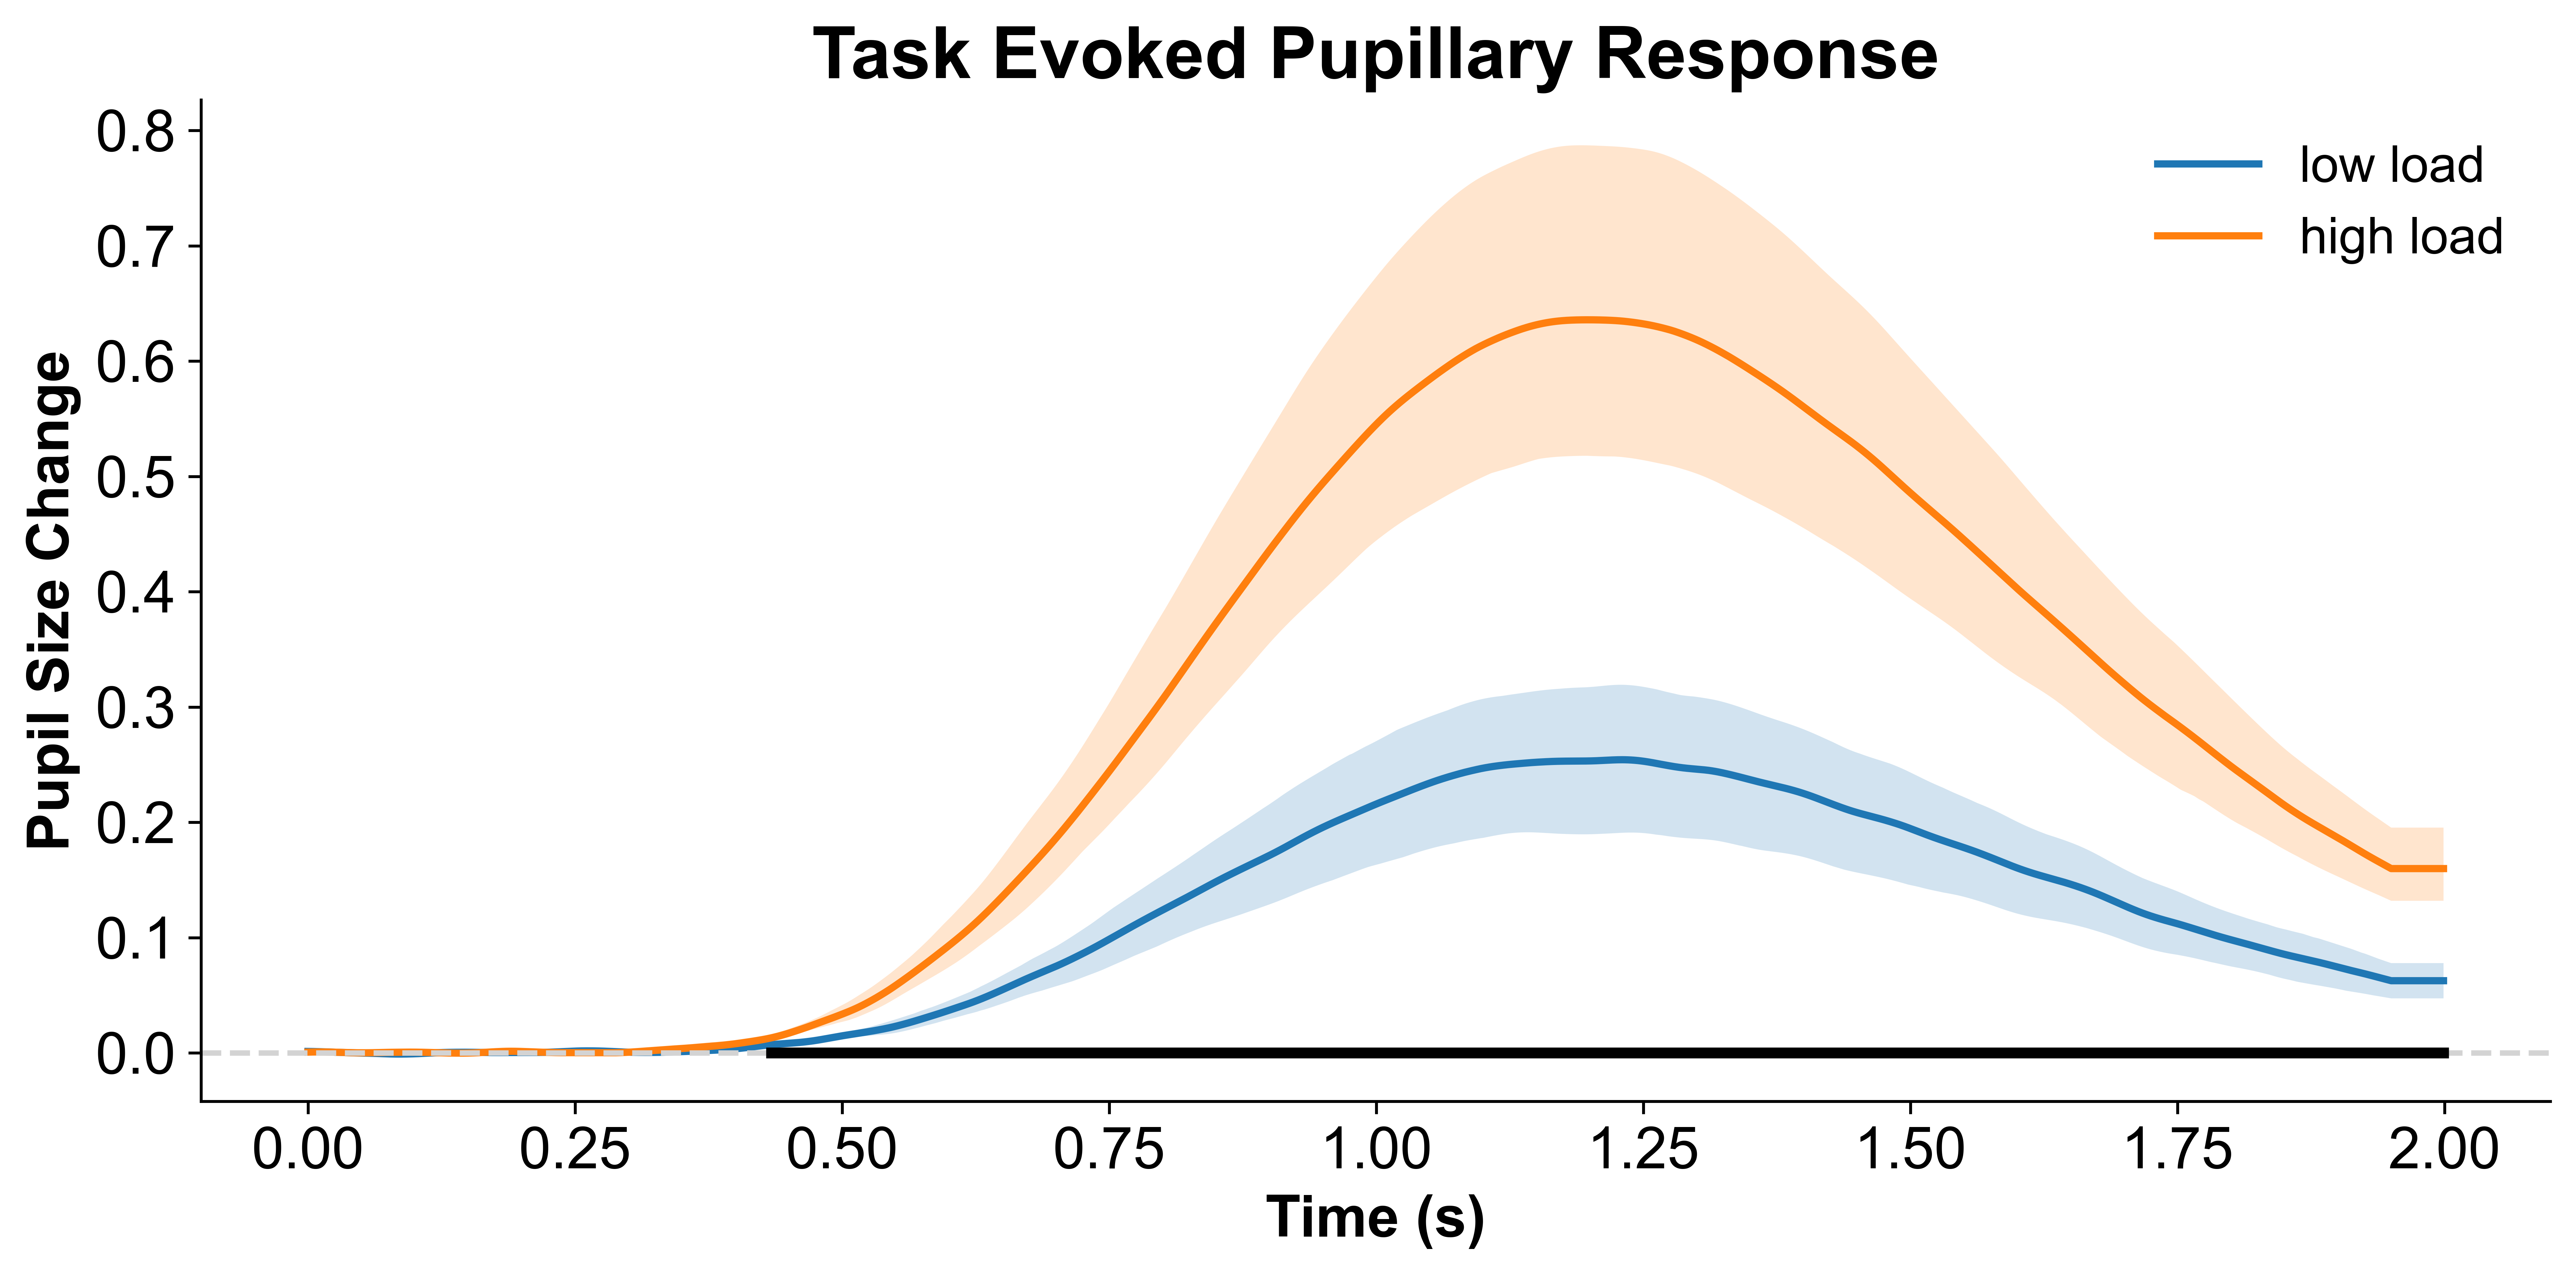

In [12]:
import matplotlib.pyplot as plt
import numpy as np

data_sub_level, (fig, ax) = p.plot_evoked(
    data='final_data', 
    agg_by='participant', # aggregate by participant
    condition='condition', 
    pupil_col='pp_final', 
    error='ci')

# baseline
ax.axhline(0, color='lightgrey', linestyle='--')

# get timestamps
t = np.arange(data_sub_level['high load'].shape[1]) / 1000 # divided by sampling rate to get time vector

# plot clusters
for i, cluster in enumerate(clusters):
    if cluster_p_values[i] < .05: # check cluster p value
        ax.plot(t[cluster], [0]*len(t[cluster]), color='black', linewidth=3)

## Q & A

### Between-subject Comparison?

If you want to compare, say, pupil response between young vs. older adults, then you will have two arrays of data instead of a single array of difference scores. You can use the `permutation_cluster_test()` provided in `mne`, which [performs a one-way ANOVA instead of an independent-sample t-test](https://mne.tools/stable/generated/mne.stats.permutation_cluster_test.html). 

```python
F_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_test(
    [data['Young'], data['Old']], # pass both conditions as a list
    threshold=None, # if None, then mne will use critical F when p = 0.5
    out_type="mask",
)
```

```{seealso}
- How not to interpret the results: https://www.fieldtriptoolbox.org/faq/stats/clusterstats_interpretation/
- `mne` API Reference: https://mne.tools/stable/generated/mne.stats.permutation_cluster_1samp_test.html
```